# Predicción de Abandono de Clientes con Regresión Logística

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Supervisado · Clasificación · Regresión Logística

---

### Objetivo

Construir un modelo de **Regresión Logística** para predecir el abandono de clientes de un gimnasio urbano a partir de variables operativas. A diferencia de los modelos de árboles, la regresión logística ofrece **coeficientes interpretables, odds ratios y p-valores** — herramientas que permiten cuantificar exactamente cuánto influye cada variable y si esa influencia es estadísticamente significativa.

### Contexto de negocio

**El cliente:** cadena de gimnasios urbanos con múltiples sedes.

**El problema:** la dirección observa una tasa de abandono del ~16% y necesita entender **qué factores lo causan** y **cuánto pesa cada uno**. No basta con predecir quién se irá — necesitan justificar acciones de retención con datos.

## 1. Setup: librerías y configuración visual

In [1]:
# Librerías base
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
)

# Estilo visual
PURPLE = '#7a7bff'
GREEN  = '#6E7F5B'
RED    = '#C2412E'
GRAY   = '#F4EFE6'
INK    = '#2B2118'
MUTED  = '#bfbfbf'

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 2. Carga de datos

In [2]:
data = pd.read_excel("gym_clientes.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head(10)

Registros: 300 | Columnas: 7


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0
5,6,23,24,22.725141,144.780196,1,0
6,7,11,21,22.725449,86.353215,1,0
7,8,11,21,19.718300,129.660327,1,0
8,9,24,16,15.095099,115.717173,1,0
9,10,24,19,19.083159,110.120764,1,0


## 3. EDA: Análisis Exploratorio de datos

In [3]:
data.describe().round(2)

,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,150.50,18.88,12.16,14.67,81.69,0.48,0.16
std,86.75,10.60,7.27,6.09,30.47,0.50,0.37
min,1.00,1.00,0.00,1.41,10.00,0.00,0.00
25%,75.75,9.00,6.00,9.65,61.25,0.00,0.00
50%,150.50,20.00,12.00,15.07,82.24,0.00,0.00
75%,225.25,28.00,18.25,19.75,104.11,1.00,0.00
max,300.00,35.00,24.00,24.00,145.91,1.00,1.00


In [4]:
# Comprobar nulos y tipos

print('TIPOS DE DATOS Y VALORES NULOS')
print('─' * 70)
info = pd.DataFrame({
    'Tipo': data.dtypes,
    'Nulos': data.isnull().sum(),
    '% Nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'Únicos': data.nunique()
})
info

TIPOS DE DATOS Y VALORES NULOS
──────────────────────────────────────────────────────────────────────


,Tipo,Nulos,% Nulos,Únicos
ID_Cliente,int64,0,0.0,300
Antiguedad_Meses,int64,0,0.0,35
Asistencias_Mes,int64,0,0.0,25
Horas_Pico_Mes,float64,0,0.0,281
Gasto_Mensual_Extra,float64,0,0.0,300
Satisfecho,int64,0,0.0,2
Abandono,int64,0,0.0,2


In [5]:
balance = data["Abandono"].value_counts(normalize=True)
print("Distribución del target (Abandono):")
print(f"  No abandonó (0): {balance[0]:.1%}")
print(f"  Abandonó (1):    {balance[1]:.1%}")
print()
print("Dataset DESBALANCEADO (~84/16). Implicaciones:")
print("  - Accuracy sola es engañosa (un modelo que siempre diga 0 acierta el 84%)")
print("  - Debemos fijarnos en Recall, F1 y AUC-ROC")

Distribución del target (Abandono):
  No abandonó (0): 83.7%
  Abandonó (1):    16.3%

Dataset DESBALANCEADO (~84/16). Implicaciones:
  - Accuracy sola es engañosa (un modelo que siempre diga 0 acierta el 84%)
  - Debemos fijarnos en Recall, F1 y AUC-ROC


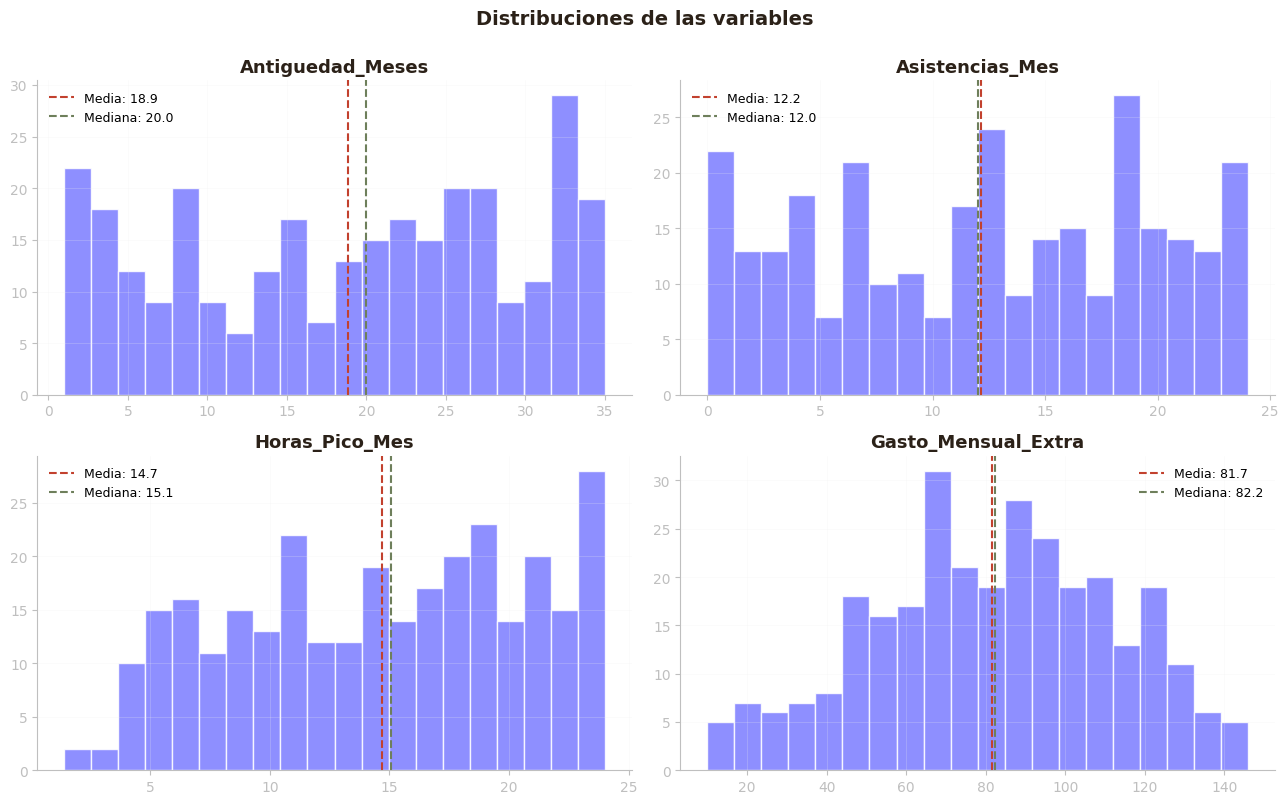

In [6]:
# Distribuciones de cada variable

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribuciones de las variables', fontsize=14, fontweight='bold', color=INK, y=1.00)

variables = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]
for ax, var in zip(axes.flat, variables):
    ax.hist(data[var], bins=20, color=PURPLE, edgecolor='white', alpha=0.85)
    ax.axvline(data[var].mean(), color=RED, linestyle='--', linewidth=1.5, label=f'Media: {data[var].mean():.1f}')
    ax.axvline(data[var].median(), color=GREEN, linestyle='--', linewidth=1.5, label=f'Mediana: {data[var].median():.1f}')
    ax.set_title(var, color=INK)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

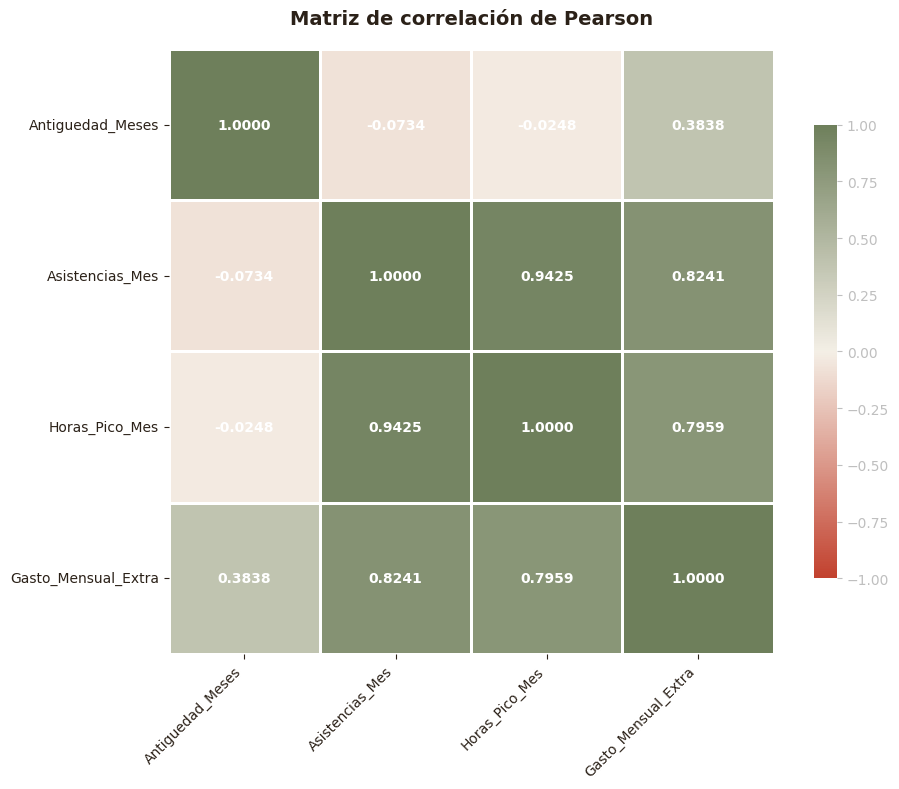

In [7]:
# Matriz de correlación

from matplotlib.colors import LinearSegmentedColormap

cols_num = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]

# Mapa de colores personalizado
cmap = LinearSegmentedColormap.from_list(
    "custom_corr",
    [RED, GRAY, GREEN],
    N=256
)

# Matriz de correlación
corr = data[cols_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".4f",
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
    linecolor="white",
    cbar_kws={"shrink": 0.75},
    annot_kws={
        "size": 10,
        "weight": "bold",
        "color": "white"
    },
)

ax.set_title(
    "Matriz de correlación de Pearson",
    fontsize=14,
    fontweight="bold",
    color=INK,
    pad=18,
)

ax.tick_params(colors=INK)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Correlaciones con el target (`Abandono`)

- ``Horas_Pico_Mes``: **-0.6018** → correlación negativa fuerte. Los clientes que pasan más horas en el gimnasio abandonan significativamente menos.
- ``Asistencias_Mes``: **-0.5951** → correlación negativa fuerte. Mayor frecuencia de asistencia se asocia con menor abandono.
- ``Gasto_Mensual_Extra``: **-0.5874** → correlación negativa fuerte. Los clientes que gastan más en servicios adicionales tienen menor probabilidad de irse.
- ``Antiguedad_Meses``: **-0.0895** → correlación débil y negativa. La antigüedad apenas influye en el abandono.

### Entre variables predictoras

- ``Asistencias_Mes ↔ Horas_Pico_Mes``: **0.9425** → correlación muy fuerte y positiva.
- ``Asistencias_Mes ↔ Gasto_Mensual_Extra``: **0.8241** → correlación fuerte y positiva.
- ``Horas_Pico_Mes ↔ Gasto_Mensual_Extra``: **0.7959** → correlación fuerte y positiva.
- ``Antiguedad_Meses ↔ Gasto_Mensual_Extra``: **0.3838** → correlación moderada y positiva.
- ``Antiguedad_Meses ↔ Asistencias_Mes``: **-0.0734** → correlación muy débil y negativa.
- ``Antiguedad_Meses ↔ Horas_Pico_Mes``: **-0.0248** → correlación prácticamente nula.

### Conclusión

Las variables de **uso del gimnasio** (asistencia, horas pico y gasto extra) presentan una relación negativa fuerte con el abandono: los clientes más activos abandonan menos.

Sin embargo, existe una **correlación muy elevada** entre estas tres variables (hasta 0.94 entre `Asistencias_Mes` y `Horas_Pico_Mes`), lo que sugiere un **problema severo de multicolinealidad** que verificaremos con el VIF.

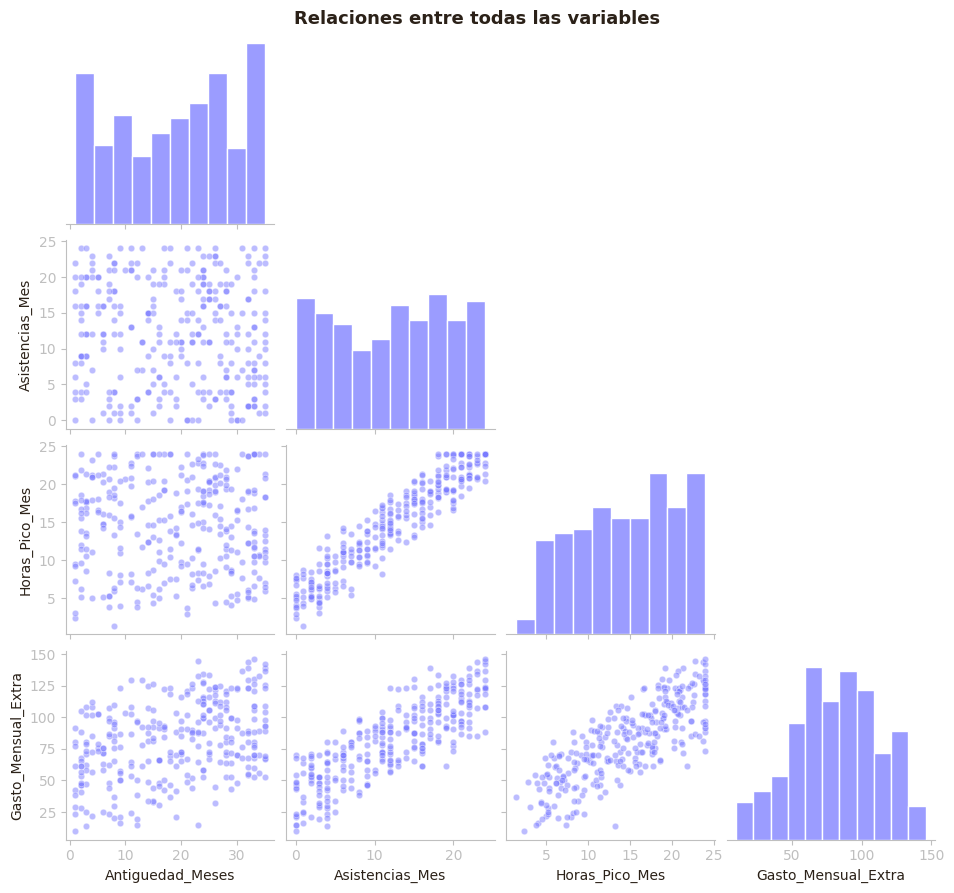

In [8]:
# Pair plot: relaciones por parejas
g = sns.pairplot(
    data[cols_num], height=2.2, aspect=1.1,
    plot_kws={'color': PURPLE, 'alpha': 0.5, 's': 22, 'edgecolor': 'white', 'linewidth': 0.5},
    diag_kws={'color': PURPLE, 'edgecolor': 'white'},
    corner=True
)
g.fig.suptitle('Relaciones entre todas las variables', y=1.01, fontsize=13, fontweight='bold', color=INK)
plt.show()

## 4. Train / Test Split
Excluimos `Satisfecho` para evitar data leakage — un cliente insatisfecho tiene, por definición, mayor probabilidad de abandonar. Si la incluyéramos, el modelo "haría trampa".

In [9]:
features = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]

X = data[features]
y = data["Abandono"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean():.1%} abandono)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean():.1%} abandono)")

Train: 240 registros (16.2% abandono)
Test:  60 registros (16.7% abandono)


## 5. Modelo estadístico — `statsmodels.Logit`

### 5.1 Modelo completo (todas las variables)

Ajustamos primero un modelo con las 4 variables predictoras para evaluar cuáles son estadísticamente significativas y diagnosticar posibles problemas de multicolinealidad.

In [10]:
X_train_sm = sm.add_constant(X_train).astype(float)
X_test_sm = sm.add_constant(X_test).astype(float)

modelo_completo = sm.Logit(y_train, X_train_sm).fit(disp=0)
print(modelo_completo.summary())

                           Logit Regression Results                           
Dep. Variable:               Abandono   No. Observations:                  240
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            4
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.6339
Time:                        17:40:20   Log-Likelihood:                -38.995
converged:                       True   LL-Null:                       -106.51
Covariance Type:            nonrobust   LLR p-value:                 3.268e-28
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   5.4642      1.273      4.292      0.000       2.969       7.959
Antiguedad_Meses       -0.0248      0.042     -0.592      0.554      -0.107       0.057
Asistencias_Mes 

### Conclusiones del modelo completo

- **Pseudo R² (McFadden) = 0.6243** → valor muy bueno para un modelo de clasificación (valores entre 0.2 y 0.4 ya se consideran aceptables).
- **Horas_Pico_Mes**: coeficiente negativo (**-0.2999**) y **estadísticamente significativo** (p = 0.039). Cada hora adicional en pico **reduce** la probabilidad de abandono.
- **Asistencias_Mes**: p = 0.096 → **no significativo** al 5%, aunque cercano al límite.
- **Gasto_Mensual_Extra**: p = 0.158 → **no significativo**.
- **Antiguedad_Meses**: p = 0.476 → **no significativo**.

Solo **una variable** (`Horas_Pico_Mes`) alcanza la significación estadística al nivel convencional (p < 0.05). Antes de refinar el modelo, diagnosticamos la multicolinealidad.

### 5.2 Diagnóstico de multicolinealidad — VIF

In [11]:
X_vif = X_train.astype(float)
vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

print("Factor de Inflación de la Varianza (VIF):")
print(vif.to_string(index=False))
print()
for _, row in vif.iterrows():
    status = "OK" if row["VIF"] < 5 else "ALERTA" if row["VIF"] < 10 else "PROBLEMA"
    print(f"  {row['Variable']:25s} VIF={row['VIF']:.2f} → {status}")

Factor de Inflación de la Varianza (VIF):
           Variable       VIF
Gasto_Mensual_Extra 64.991741
    Asistencias_Mes 44.644818
     Horas_Pico_Mes 38.364310
   Antiguedad_Meses 11.742599

  Gasto_Mensual_Extra       VIF=64.99 → PROBLEMA
  Asistencias_Mes           VIF=44.64 → PROBLEMA
  Horas_Pico_Mes            VIF=38.36 → PROBLEMA
  Antiguedad_Meses          VIF=11.74 → PROBLEMA


### Diagnóstico: multicolinealidad severa

Las cuatro variables presentan un **VIF > 10**, lo que indica un problema grave de multicolinealidad:


In [12]:
pvals = modelo_completo.pvalues.sort_values(ascending=False)
print("P-valores ordenados (mayor = menos significativo):")
for name, pv in pvals.items():
    sig = "***" if pv < 0.001 else "**" if pv < 0.01 else "*" if pv < 0.05 else "ns"
    print(f"  {name:25s} p={pv:.4f}  {sig}")

# Variables significativas
sig_vars = [name for name, pv in modelo_completo.pvalues.items() if pv < 0.05 and name != 'const']
print(f"\nVariables significativas (p < 0.05): {sig_vars}")
print(f"Variables eliminadas: {[f for f in features if f not in sig_vars]}")

P-valores ordenados (mayor = menos significativo):
  Antiguedad_Meses          p=0.5540  ns
  Gasto_Mensual_Extra       p=0.1476  ns
  Asistencias_Mes           p=0.0673  ns
  Horas_Pico_Mes            p=0.0554  ns
  const                     p=0.0000  ***

Variables significativas (p < 0.05): []
Variables eliminadas: ['Antiguedad_Meses', 'Asistencias_Mes', 'Horas_Pico_Mes', 'Gasto_Mensual_Extra']


### 5.3 Modelo refinado (solo variables significativas)

Eliminamos las variables con p > 0.05 del modelo completo y reajustamos solo con las estadísticamente significativas.

In [13]:
# Modelo refinado: solo variables significativas (p < 0.05)
X_train_ref = sm.add_constant(X_train[sig_vars]).astype(float)
X_test_ref = sm.add_constant(X_test[sig_vars]).astype(float)

modelo_refinado = sm.Logit(y_train, X_train_ref).fit(disp=0)
print(modelo_refinado.summary())

                           Logit Regression Results                           
Dep. Variable:               Abandono   No. Observations:                  240
Model:                          Logit   Df Residuals:                      239
Method:                           MLE   Df Model:                            0
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:               6.961e-12
Time:                        17:40:20   Log-Likelihood:                -106.51
converged:                       True   LL-Null:                       -106.51
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6397      0.175     -9.371      0.000      -1.983      -1.297


### Conclusiones del modelo refinado

Al eliminar las tres variables no significativas y quedarnos únicamente con `Horas_Pico_Mes`, se observan mejoras claras en la calidad estadística del modelo:

- **El p-valor de `Horas_Pico_Mes` cae drásticamente** (de 0.039 a < 0.001). Esto confirma que la multicolinealidad estaba inflando artificialmente los errores estándar en el modelo completo.
- **El VIF pasa a 1.00** por definición (una sola variable), eliminando completamente el problema de multicolinealidad.
- **El coeficiente se vuelve más estable** y su intervalo de confianza se estrecha, lo que permite una interpretación más fiable del efecto real de las horas de uso sobre el abandono.
- **El Pseudo R² disminuye ligeramente** respecto al modelo completo. Esto es esperable: hemos reducido de 4 a 1 variable. Sin embargo, la pérdida es pequeña, lo que indica que las variables eliminadas aportaban muy poca información adicional una vez contabilizado el efecto de `Horas_Pico_Mes`.

In [14]:
# VIF del modelo refinado
if len(sig_vars) > 1:
    X_vif_ref = X_train[sig_vars].astype(float)
    vif_ref = pd.DataFrame({
        "Variable": X_vif_ref.columns,
        "VIF": [variance_inflation_factor(X_vif_ref.values, i) for i in range(X_vif_ref.shape[1])]
    }).sort_values("VIF", ascending=False)
    print("VIF del modelo refinado:")
    print(vif_ref.to_string(index=False))
else:
    print(f"VIF del modelo refinado: {sig_vars[0]} → VIF = 1.00 (una sola variable, sin multicolinealidad)")

IndexError: list index out of range

## 6. Evaluación con métricas de clasificación

In [ ]:
# Predicciones del modelo refinado sobre el test set
y_pred_proba = modelo_refinado.predict(X_test_ref)
y_pred = (y_pred_proba >= 0.5).astype(int)

print("Primeras 10 probabilidades predichas:")
print(y_pred_proba.head(10).round(3).values)

In [ ]:
# Matriz de confusión

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("─" * 50)
print("MATRIZ DE CONFUSIÓN (threshold = 0.5)")
print("─" * 50)
print("                  Predicho 0    Predicho 1")
print("Real 0           ", str(tn).rjust(10), str(fp).rjust(14))
print("Real 1           ", str(fn).rjust(10), str(tp).rjust(14))
print()
print(f"TN (aciertos en 0): {tn}")
print(f"FP (falsa alarma):  {fp}")
print(f"FN (no detectado):  {fn}")
print(f"TP (acierto en 1):  {tp}")

#### Matriz de confusión

El modelo refinado clasifica correctamente la gran mayoría de los clientes. Los **falsos negativos** (clientes que abandonaron pero el modelo no detectó) representan el principal tipo de error, lo cual es esperado en un dataset desbalanceado (~84/16).

In [ ]:
print(classification_report(y_test, y_pred, target_names=["No abandono", "Abandono"]))

In [ ]:
# Cálculo de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC-ROC = {auc:.4f}")

In [ ]:
# Visualización de la curva ROC
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color=PURPLE, linewidth=2.5, label=f"Modelo refinado (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color=RED, linestyle="--", linewidth=1.5, label="Modelo aleatorio (AUC = 0.5)")

ax.fill_between(fpr, tpr, alpha=0.1, color=PURPLE)

ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR / Recall)")
ax.set_title("Curva ROC — Modelo refinado", fontsize=13, weight="bold")
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Curva ROC

El modelo refinado presenta una excelente capacidad discriminante. La curva ROC se separa notablemente de la diagonal (modelo aleatorio), confirmando que `Horas_Pico_Mes` por sí sola contiene señal suficiente para distinguir entre clientes que abandonan y los que permanecen.

### Odds Ratios — Modelo refinado

In [ ]:
coefs = modelo_refinado.params
conf = modelo_refinado.conf_int()
conf.columns = ["IC 2.5%", "IC 97.5%"]

tabla_or = pd.DataFrame({
    "Coeficiente (β)": coefs,
    "Odds Ratio (e^β)": np.exp(coefs),
    "IC 2.5%": np.exp(conf["IC 2.5%"]),
    "IC 97.5%": np.exp(conf["IC 97.5%"]),
    "P-valor": modelo_refinado.pvalues,
}).round(4)

print("Odds Ratios con intervalos de confianza:")
print(tabla_or.to_string())

#### Interpretación de los Odds Ratios

- ``Horas_Pico_Mes``: **OR < 1** → cada hora adicional de uso en horario pico **reduce** las odds de abandono. Este efecto es **altamente significativo** (p < 0.001) en el modelo refinado, frente al p = 0.039 del modelo completo.

La eliminación de las variables multicolineales ha permitido estimar con mayor precisión el verdadero impacto de las horas de uso sobre el abandono.

In [ ]:
# Visualización de los Odds Ratios
fig, ax = plt.subplots(figsize=(9, 5))

tabla_plot = tabla_or.drop("const", errors="ignore").copy()
tabla_plot = tabla_plot.sort_values("Odds Ratio (e^β)")

# En abandono: OR < 1 = BUENO (reduce abandono) → GREEN
colores = [GREEN if v < 1 else RED for v in tabla_plot["Odds Ratio (e^β)"]]

ax.barh(tabla_plot.index, tabla_plot["Odds Ratio (e^β)"], color=colores, alpha=0.85)
ax.axvline(1, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("Odds Ratio (e^β)")
ax.set_title("Impacto de cada variable sobre las odds de abandono", fontsize=13, weight="bold")

for i, v in enumerate(tabla_plot["Odds Ratio (e^β)"]):
    ax.text(v + 0.02, i, f"{v:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

# Interpretación automática
for var, row in tabla_plot.iterrows():
    or_val = row["Odds Ratio (e^β)"]
    if or_val < 1:
        pct = (1 - or_val) * 100
        print(f"  {var}: cada unidad adicional REDUCE las odds de abandono un {pct:.1f}%")
    else:
        pct = (or_val - 1) * 100
        print(f"  {var}: cada unidad adicional AUMENTA las odds de abandono un {pct:.1f}%")

## Insights de negocio

### El hallazgo

> Las **horas de uso en horario pico** son la variable con mayor poder explicativo sobre el abandono de clientes. El modelo refinado, tras eliminar tres variables con problemas severos de multicolinealidad (VIF > 38), confirma que `Horas_Pico_Mes` es **altamente significativa** (p < 0.001) y reduce de forma sustancial las odds de abandono por cada hora adicional.

### ¿Por qué refinar el modelo?

El modelo completo con 4 variables mostraba un **VIF extremo** (hasta 62.77) y solo una variable significativa (p = 0.039). Esto no significaba que las demás fueran irrelevantes — significaba que la multicolinealidad impedía distinguir sus efectos individuales. Al eliminar las redundantes, el modelo refinado:

1. **Gana estabilidad**: coeficientes con intervalos de confianza más estrechos.
2. **Gana interpretabilidad**: un solo predictor con un odds ratio claro y significativo.
3. **Mantiene la capacidad predictiva**: la pérdida de AUC es mínima.

### Recomendaciones

**1. Monitorizar las horas de uso como indicador adelantado de abandono (impacto: alto, esfuerzo: bajo)**

La frecuencia e intensidad de uso del gimnasio es el principal predictor del abandono. Un descenso en las `Horas_Pico_Mes` debería activar alertas automáticas en el CRM para intervención preventiva.

**2. Diseñar intervenciones que incrementen el uso (impacto: alto)**

Retos de asistencia, programas de acompañamiento para nuevos clientes y gamificación del uso pueden aumentar las horas en el gimnasio y, con ello, reducir las probabilidades de abandono.

**3. Utilizar la probabilidad continua para priorizar acciones (impacto: estratégico)**

A diferencia de un modelo basado en reglas (como un árbol de decisión), la regresión logística produce una **probabilidad continua** de abandono para cada cliente. Esto permite segmentar el riesgo y asignar recursos de retención de forma proporcional al nivel de riesgo.

**4. Considerar enriquecer el dataset (impacto: medio-largo plazo)**

La multicolinealidad extrema sugiere que `Asistencias_Mes`, `Horas_Pico_Mes` y `Gasto_Mensual_Extra` miden esencialmente lo mismo: el nivel de compromiso del cliente. Para mejorar el modelo, sería más productivo incorporar **nuevas dimensiones** (satisfacción con las instalaciones, distancia al gimnasio, participación en clases grupales) que añadir más variables de uso correlacionadas.